# Neural Language Model Scoring
## Using GPT-2 for Acceptability Hypothesis Testing

> **Model used:**
> - `gpt2` — OpenAI GPT-2 (small), 124M params, via HuggingFace `transformers`

---

## 0. Install Dependencies

In [15]:
import subprocess, sys

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "transformers",
        "torch",
        "scipy",
        "pandas",
        "matplotlib",
        "tqdm",
        "ipywidgets",
        "jupyter",
        "--quiet",
    ]
)
print("Dependencies ready.")

Dependencies ready.


In [16]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from tqdm import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BNC_CSV = "bnc.csv"

print(f"Using device: {DEVICE}")

Using device: cpu


## 1. Load BNC Dataset

In [17]:
bnc = pd.read_csv(BNC_CSV, sep="\t")
sentences = bnc["text"].tolist()
human_ratings = bnc["mean_rating"].values
print(f"Loaded {len(sentences):,} BNC sentences.")
bnc.head(3)

Loaded 5,250 BNC sentences.


,MOP,language,text,length,rating_list,mean_rating
0,MOP2,en,"We've still got the Dower House , and Lincolns...",12,"4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4",4.0
1,MOP2,en,My first real friend was probably a boy called...,10,"4, 4, 4, 4, 4, 4, 4, 4, 4, 4",4.0
2,MOP2,en,She was wearing denim overalls and carrying a ...,11,"4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4",4.0


In [18]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast

print("Loading GPT-2...")
gpt2_tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
gpt2_model = GPT2LMHeadModel.from_pretrained("gpt2").to(DEVICE)
gpt2_model.eval()
print("GPT-2 loaded.")

Loading GPT-2...
GPT-2 loaded.


In [19]:
def gpt2_sentence_scores(sentence, model, tokenizer, device):
    enc = tokenizer(sentence, return_tensors="pt").to(device)
    input_ids = enc["input_ids"]
    n_tokens = input_ids.shape[1]

    with torch.no_grad():
        outputs = model(input_ids, labels=input_ids)
        mean_nll = outputs.loss.item()

    total_log_prob = -mean_nll * n_tokens
    return total_log_prob, n_tokens


print("Scoring sentences with GPT-2 (this may take a few minutes)...")
gpt2_results = []
for sent in tqdm(sentences, desc="GPT-2"):
    lp, n = gpt2_sentence_scores(sent, gpt2_model, gpt2_tokenizer, DEVICE)
    gpt2_results.append((lp, n))

print(f"Done. Scored {len(gpt2_results)} sentences.")

Scoring sentences with GPT-2 (this may take a few minutes)...


GPT-2: 100%|██████████| 5250/5250 [18:51<00:00,  4.64it/s]

Done. Scored 5250 sentences.


## 3. GPT-2 Unigram Baseline for SLOR

In [22]:
from collections import Counter

BROWN_TRAIN = "./brown-train.txt"


def load_tokens(path):
    tokens = []
    try:
        with open(path, encoding="utf-8", errors="ignore") as f:
            for line in f:
                tokens.extend(line.lower().split())
    except FileNotFoundError:
        pass
    return tokens


all_tokens = load_tokens(BROWN_TRAIN)
total = len(all_tokens)
uni_counts = Counter(all_tokens)
print(f"Unigram vocab size: {len(uni_counts):,} types from {total:,} tokens")

LOG_UNK = np.log(1 / (total + 1))  # fallback for OOV


def sentence_unigram_logprob(sentence):
    tokens = sentence.lower().split()
    lp = 0.0
    for t in tokens:
        cnt = uni_counts.get(t, 1)  # add-1 smoothing
        lp += np.log(cnt / (total + len(uni_counts)))
    return lp


uni_logprobs = np.array([sentence_unigram_logprob(s) for s in sentences])
print("Unigram log-probs computed.")

Unigram vocab size: 36,585 types from 729,282 tokens
Unigram log-probs computed.


## 4. Assemble GPT-2 Scores DataFrame

In [31]:
scored_neural = bnc.copy()

gpt2_logprobs = np.array([lp for lp, _ in gpt2_results])
gpt2_ntokens = np.array([n for _, n in gpt2_results])

scored_neural["gpt2_log_prob"] = gpt2_logprobs
scored_neural["gpt2_mean_log_prob"] = gpt2_logprobs / gpt2_ntokens
scored_neural["gpt2_slor"] = gpt2_logprobs - uni_logprobs

scored_neural[
        ["text", "mean_rating", "gpt2_log_prob", "gpt2_mean_log_prob", "gpt2_slor"]].to_csv("scored_neural.csv", index=False)

print(
    scored_neural[
        ["text", "mean_rating", "gpt2_log_prob", "gpt2_mean_log_prob", "gpt2_slor"]
    ].head(5)
)

                                                text  mean_rating  \
0  We've still got the Dower House , and Lincolns...     4.000000   
1  My first real friend was probably a boy called...     4.000000   
2  She was wearing denim overalls and carrying a ...     4.000000   
3  In the next year he had custody of Rochester C...     3.812500   
4  BOOKING is essential for a cycle ride around W...     3.076923   

   gpt2_log_prob  gpt2_mean_log_prob  gpt2_slor  
0    -111.458062           -5.866214   1.520675  
1     -48.585708           -4.416883  29.442360  
2     -63.250198           -4.865400  29.218466  
3     -60.826404           -5.529673  17.520222  
4    -149.610190           -5.541118  49.069183  


## 5. Spearman Correlation — GPT-2

In [24]:
score_cols = [
    ("gpt2_log_prob", "GPT-2 — log P"),
    ("gpt2_mean_log_prob", "GPT-2 — mean log P"),
    ("gpt2_slor", "GPT-2 — SLOR"),
]

print(f"{'Score':<25}  {'Spearman':>12}  {'p-value':>12}")
print("-" * 55)

neural_results = []
for col, label in score_cols:
    rho, p = spearmanr(scored_neural[col], human_ratings)
    neural_results.append({"Label": label, "Spearman": rho, "p-value": p})
    print(f"{label:<25}  {rho:>12.4f}  {p:>12.4e}")

nr_df = pd.DataFrame(neural_results)

Score                          Spearman       p-value
-------------------------------------------------------
GPT-2 — log P                    0.3554   4.3223e-156
GPT-2 — mean log P               0.4880    0.0000e+00
GPT-2 — SLOR                     0.3633   1.3941e-163


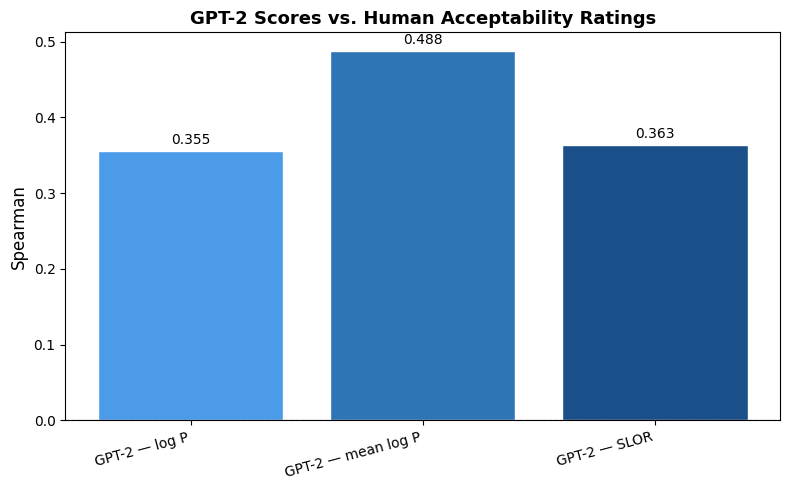

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#4C9BE8", "#2E75B6", "#1B4F8A"]
bars = ax.bar(nr_df["Label"], nr_df["Spearman"], color=colors, edgecolor="white")
for bar, row in zip(bars, nr_df.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{row.Spearman:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("Spearman", fontsize=12)
ax.set_title(
    "GPT-2 Scores vs. Human Acceptability Ratings", fontsize=13, fontweight="bold"
)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("gpt2_spearman.png", dpi=150)
plt.show()